In [2]:
import os, numpy as np, pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# kalau kamu pakai seaborn
import seaborn as sns

In [5]:
import os
from PIL import Image
from tqdm import tqdm
import pandas as pd

# --- KHUSUS HEIC ---
# Daftarkan pembaca HEIC agar Image.open() bisa membacanya
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    print("Support HEIC berhasil diaktifkan.")
except ImportError:
    print("Library 'pillow-heif' belum terinstall. Jalankan '!pip install pillow-heif' dulu.")

# ==========================================
# KONVERSI SEMUA DATA (TERMASUK HEIC) KE PNG
# ==========================================

output_base_dir = 'Dataset New EF'  # Folder tujuan
print(f"\nMemulai konversi gambar ke PNG...")
print(f"Data akan disimpan di: {output_base_dir}")

new_data_list = []
error_files = []

# Menggunakan tqdm untuk progress bar
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Converting"):
    src_path = row['filepath']
    label = row['label']  
    
    # 1. Persiapan Folder Tujuan
    parts = label.split() 
    variation_folder = parts[0] # V1
    quality_folder = parts[1]   # FRESH
    
    target_folder = os.path.join(output_base_dir, quality_folder, variation_folder)
    os.makedirs(target_folder, exist_ok=True)
    
    # 2. Nama File Baru (.png)
    file_name = os.path.basename(src_path)
    name_without_ext = os.path.splitext(file_name)[0]
    new_filename = f"{name_without_ext}.png"
    dst_path = os.path.join(target_folder, new_filename)
    
    # 3. Proses Konversi
    try:
        # Image.open sekarang sudah bisa buka HEIC karena register_heif_opener()
        with Image.open(src_path) as img:
            
            # Convert ke RGB 
            # (Penting: HEIC/PNG bisa punya alpha channel/transparansi, 
            # untuk deep learning amannya dipaksa ke RGB 3-channel)
            img = img.convert('RGB')
            
            # Simpan sebagai PNG
            img.save(dst_path, 'PNG')
            
            # Masukkan path baru ke list
            new_data_list.append({'filepath': dst_path, 'label': label})
            
    except Exception as e:
        print(f"\n[ERROR] Gagal: {src_path} | Error: {e}")
        error_files.append(src_path)

# ==========================================
# UPDATE DATAFRAME
# ==========================================
df_png = pd.DataFrame(new_data_list)
df = df_png # Timpa df lama dengan data PNG baru

print("\n" + "="*40)
print("KONVERSI SELESAI")
print("="*40)
print(f"Total Asli  : {len(df) + len(error_files)}")
print(f"Berhasil PNG: {len(df_png)}")
print(f"Gagal       : {len(error_files)}")

if len(error_files) > 0:
    print("Contoh file gagal:", error_files[:3])

Support HEIC berhasil diaktifkan.

Memulai konversi gambar ke PNG...
Data akan disimpan di: Dataset New EF


Converting: 100%|██████████| 80/80 [00:23<00:00,  3.40it/s]


KONVERSI SELESAI
Total Asli  : 80
Berhasil PNG: 80
Gagal       : 0


In [31]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & PERSIAPAN DATA
# ==========================================


# --- KONFIGURASI FOLDER ---
# Pastikan path ini sesuai dengan di Drive Anda
base_dir = 'Dataset New EF'

# List Variasi dan Kualitas sesuai struktur folder Anda
qualities = ['FRESH', "SPOILED"]
# qualities = ['FRESH']
variations = ['V1', 'V2', 'V3', 'V4']
print("Sedang memindai file dan membuat label...")

data_list = []

# Loop untuk membaca file dari struktur folder
for quality in qualities:

  for variation in variations:
      # Menyusun path: .../TANPA LEMPUK/FRESH/Variasi 1
      folder_path = os.path.join(base_dir, quality, variation)
        
      if os.path.exists(folder_path):
          files = os.listdir(folder_path)
          for file_name in files:
              if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                  # Membuat Label: "Variasi 1 FRESH", dst.
                  label_name = f"{variation} {quality}" 
                  full_path = os.path.join(folder_path, file_name)
                  data_list.append({'filepath': full_path, 'label': label_name})
      else:
          print(f"Warning: Folder tidak ditemukan -> {folder_path}")

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Ditemukan: {len(df)}")
print(f"Jumlah Kelas: {df['label'].nunique()}")

# Cek distribusi data
print("\nJumlah data per kelas:")
print(df['label'].value_counts())




Sedang memindai file dan membuat label...

Total Data Ditemukan: 80
Jumlah Kelas: 8

Jumlah data per kelas:
label
V1 FRESH      10
V2 FRESH      10
V3 FRESH      10
V4 FRESH      10
V1 SPOILED    10
V2 SPOILED    10
V3 SPOILED    10
V4 SPOILED    10
Name: count, dtype: int64


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (150, 150)  # samakan dengan training kamu
BATCH_SIZE = 32

# preprocessing: sesuaikan dengan backbone kamu saat training
# DenseNet biasanya pakai preprocess_input dari tf.keras.applications.densenet
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # ✅ harus string
    shuffle=False
)
class_names = list(test_gen.class_indices.keys())
print(class_names)

Found 80 validated image filenames belonging to 8 classes.
['V1 FRESH', 'V1 SPOILED', 'V2 FRESH', 'V2 SPOILED', 'V3 FRESH', 'V3 SPOILED', 'V4 FRESH', 'V4 SPOILED']


In [35]:
import tensorflow as tf

MODEL_PATH = "Exp1_DenseNet121_Dengan_Lempuk_2_best_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded:", MODEL_PATH)

Model loaded: Exp1_DenseNet121_Dengan_Lempuk_2_best_model.keras


C:\Users\Azvaden\Desktop\mataikansegar-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
              precision    recall  f1-score   support

    V1 FRESH     0.6667    0.8000    0.7273        10
  V1 SPOILED     0.4706    0.8000    0.5926        10
    V2 FRESH     1.0000    0.2000    0.3333        10
  V2 SPOILED     0.4000    1.0000    0.5714        10
    V3 FRESH     0.7500    0.3000    0.4286        10
  V3 SPOILED     0.8571    0.6000    0.7059        10
    V4 FRESH     0.7778    0.7000    0.7368        10
  V4 SPOILED     0.5000    0.2000    0.2857        10

    accuracy                         0.5750        80
   macro avg     0.6778    0.5750    0.5477        80
weighted avg     0.6778    0.5750    0.5477        80



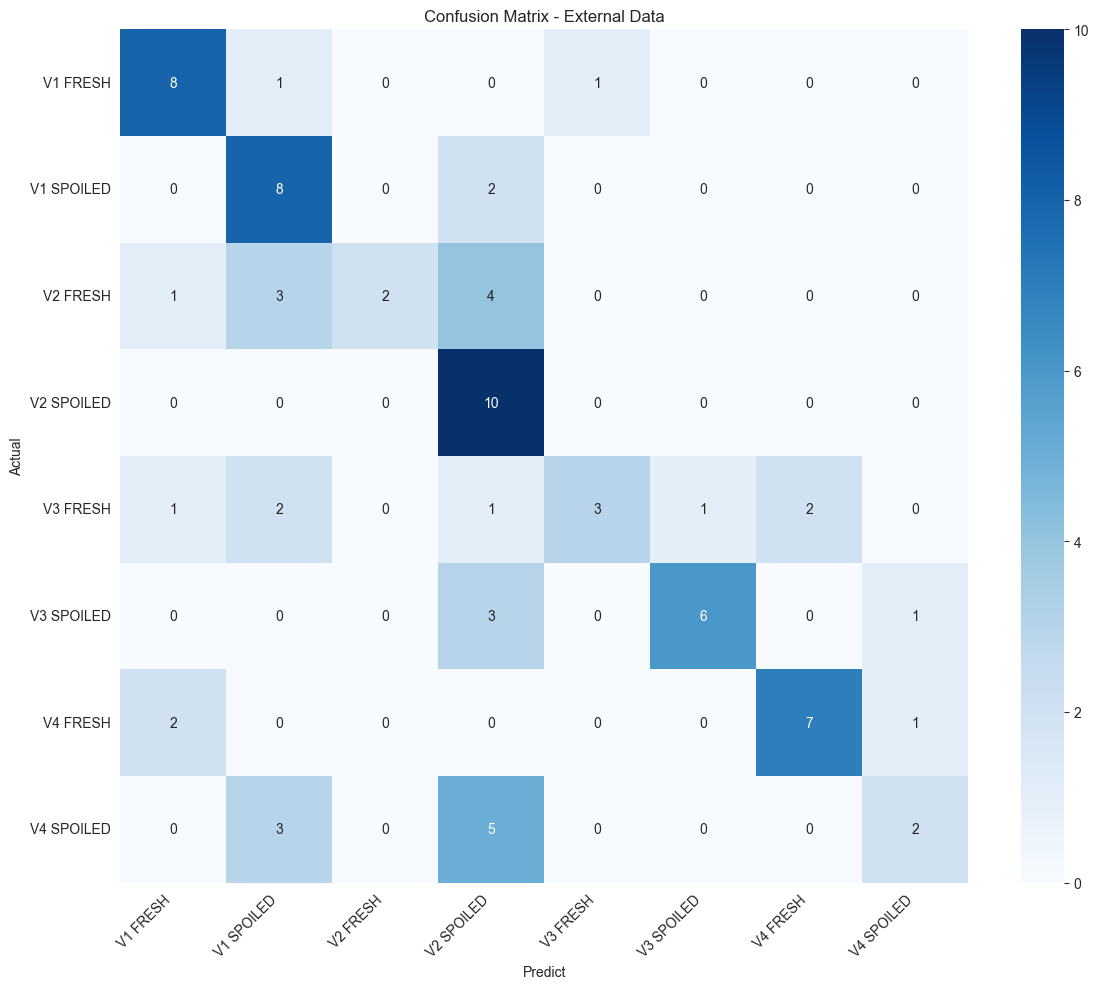

In [36]:
# prediksi
pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes  # sudah sesuai urutan data karena shuffle=False

# report
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.title("Confusion Matrix - External Data")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()